1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


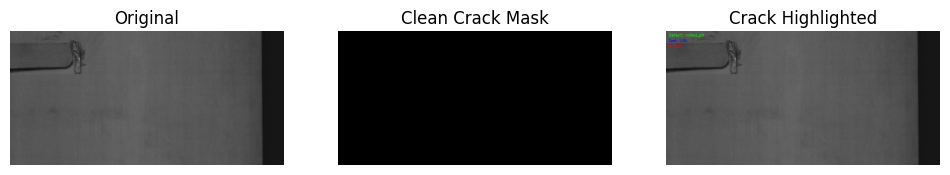


✅ RESULT:
Defect Type: rolled_pit
Confidence: 1.0
Defect %: 0.0


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ================= LOAD MODEL =================
model = load_model(r"C:\Users\yasht\Desktop\CV_FINAL\defect_classifier.h5")

classes = ["inclusion", "rolled_pit", "silk_spot", "waist folding", "crack"]

# ================= FUNCTION =================
def predict_defect(image_path):

    img = cv2.imread(image_path)

    if img is None:
        print("❌ Image not found")
        return

    # ================= PREPROCESS =================
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # noise removal
    gray = cv2.medianBlur(gray, 5)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    edges = cv2.Canny(blur, 30, 120)

    # dilation (thin cracks boost)
    kernel = np.ones((3,3), np.uint8)
    edges = cv2.dilate(edges, kernel, iterations=1)

    # 🔥 controlled connection (not too aggressive)
    kernel_close = np.ones((3,3), np.uint8)
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel_close)

    # ================= CONTOUR FILTER =================
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    mask = np.zeros_like(edges)

    for cnt in contours:
        area = cv2.contourArea(cnt)

        if area > 80:   # keep small cracks
            x, y, w, h = cv2.boundingRect(cnt)

            # 🔥 KEY: elongation filter
            aspect_ratio = max(w, h) / (min(w, h) + 1)

            if aspect_ratio > 3:   # crack-like only
                cv2.drawContours(mask, [cnt], -1, 255, -1)

    # ================= ML INPUT =================
    resized = cv2.resize(edges, (128,128))
    input_img = resized.reshape(1,128,128,1) / 255.0

    pred = model.predict(input_img)
    class_id = np.argmax(pred)
    label = classes[class_id]
    confidence = np.max(pred)

    # ================= DEFECT % =================
    defect_pixels = np.sum(mask > 0)
    total_pixels = mask.size
    percentage = (defect_pixels / total_pixels) * 100

    # ================= FORCE CRACK =================
    if percentage > 3:
        label = "crack"

    # ================= HIGHLIGHT =================
    output = img.copy()

    red_overlay = np.zeros_like(img)
    red_overlay[:, :, 2] = 255

    alpha = 0.6
    mask_3ch = cv2.merge([mask, mask, mask])

    output = np.where(mask_3ch > 0,
                      cv2.addWeighted(output, 1-alpha, red_overlay, alpha, 0),
                      output)

    # ================= TEXT =================
    color = (0,0,255) if label == "crack" else (0,255,0)

    cv2.putText(output, f"Defect: {label}", (20,40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    cv2.putText(output, f"Conf: {confidence:.2f}", (20,80),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,0,0), 2)

    cv2.putText(output, f"%: {percentage:.2f}", (20,120),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,255), 2)

    # ================= DISPLAY =================
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Clean Crack Mask")
    plt.imshow(mask, cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title("Crack Highlighted")
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()

    # ================= PRINT =================
    print("\n✅ RESULT:")
    print("Defect Type:", label)
    print("Confidence:", round(confidence,2))
    print("Defect %:", round(percentage,2))


# ================= CALL =================
predict_defect(r"C:\Users\yasht\Desktop\dataset\images\images\rolled_pit\img_03_4403715000_00003.jpg")